The Structured Output Design Pattern in agentic AI is about forcing an AI agent to return responses in a predefined, machine-readable format (like JSON, XML, or a typed schema) instead of free-form text

In [1]:
from langchain_community.tools.tavily_search import  TavilySearchResults
from langchain_core.tools import tool
from pydantic import BaseModel,Field
from langgraph.graph import MessagesState,StateGraph,END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm=ChatGroq(model="llama-3.1-8b-instant")

In [3]:
tavily_tool=TavilySearchResults()

/var/folders/qz/mw466yp17txddtx0y1qsb1q00000gn/T/ipykernel_2169/3317840929.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool=TavilySearchResults()


In [4]:
@tool
def get_city_details(prompt):
    """Should do a web search to find the required city details"""
    response=tavily_tool.invoke(prompt)
    return response

In [5]:
tools=[get_city_details]

In [6]:
llm_with_tools=llm.bind_tools(tools)

In [7]:
## Making a structured output in which the model will give the reply to the user

class CityDetails(BaseModel):
    """Respond to the user with this"""
    state_name: str = Field(description="State name of the city")
    state_capital: str = Field(description="State capital of the city")
    country_name: str = Field(description="Country name of the city")
    country_capital: str = Field(description="Country capital of the city")

In [8]:
class AgentState(MessagesState):
    final_response:CityDetails

In [9]:
model_with_structured_output=llm.with_structured_output(CityDetails)

In [10]:
## model node

def call_model(state:AgentState):
    response=llm_with_tools.invoke(state["messages"])
    return {"messages":[response]}

In [11]:
## conditional node

def should_continue(state:AgentState):
    messages=state["messages"]
    last_message=messages[-1]

    if not last_message.tool_calls:
        return "respond"
    else:
        return "continue"

In [12]:
## respond node (will convert the response from the llm to structured output)

def respond(state:AgentState):
    response=model_with_structured_output.invoke([HumanMessage(content=state['messages'][-1].content)])

    return {"final_response":response}

In [13]:
# Define a new graph
workflow = StateGraph(AgentState)

In [14]:
workflow.add_node("llm",call_model)
workflow.add_node("tools",ToolNode(tools))
workflow.add_node("respond",respond)

In [15]:
workflow.set_entry_point("llm")
workflow.add_conditional_edges(
    "llm",
    should_continue,
    {
        "continue":"tools",
        "respond":"respond"
    }
)
workflow.add_edge("tools","llm")
workflow.add_edge("respond",END)

In [16]:
app=workflow.compile()

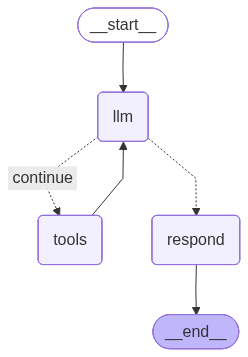

In [17]:
from IPython.display import Image, display
# View
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
answer = app.invoke(input={"messages": [("human", "Tell me about the city details for gwalior?")]})['final_response']

In [21]:
answer

CityDetails(state_name='Madhya Pradesh', state_capital='Bhopal', country_name='India', country_capital='New Delhi')